In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from google.colab.patches import cv2_imshow

In [ ]:
colorFrames = []
grayFrames = []
dir = "/content/drive/MyDrive/AVP Project/Original Frames/"
for frame in sorted(os.listdir(dir)):
    frameOriginal = cv2.imread(dir + frame)
    colorFrames.append(frameOriginal)
    gray = cv2.cvtColor(frameOriginal, cv2.COLOR_BGR2GRAY)
    grayFrames.append(gray)

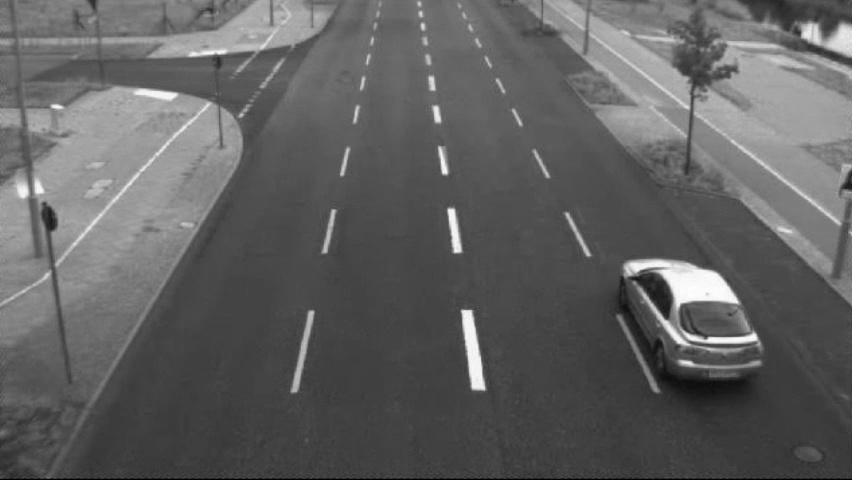

In [ ]:
cv2_imshow(grayFrames[50])
size = grayFrames[50].shape

In [ ]:
framesDiff=[]
for i in range(1,len(grayFrames)):
  frameDifference = abs(grayFrames[i]-grayFrames[i-1])
  framesDiff.append(frameDifference) #residual frames

In [ ]:
keyFrames = []
for i in range(len(framesDiff)):
  if(np.average(framesDiff[i]) > 50):
    keyFrames.append(grayFrames[i])

In [ ]:
out = cv2.VideoWriter('KeyFrames.avi',cv2.VideoWriter_fourcc(*'DIVX'), 15, (852,480), isColor=False)

for i in range(len(keyFrames)):
    out.write(keyFrames[i])
out.release()

In [ ]:
distNums = 5
trainFramesNum = 10

stdArr = np.arange(1,6)
meansArr = np.arange(1,6) * 2
weightArr = np.arange(0.25,1.5,0.25)

In [ ]:
stdArr

array([1, 2, 3, 4, 5])

In [ ]:
np.var(keyFrames[0])
size = keyFrames[0].shape

In [ ]:
def gauss(x,mean,std):
    return (1/(np.sqrt(2*3.14)*std))*(np.exp(-0.5*(((x-mean)/std)**2)))

In [ ]:
zResults = []
# for cur in keyFrames:
for curDist in range(5):
  z = gauss(cur, meansArr[curDist], stdArr[curDist]) * weightArr[curDist]
  np.nan_to_num(z)
  zResults.append(z)

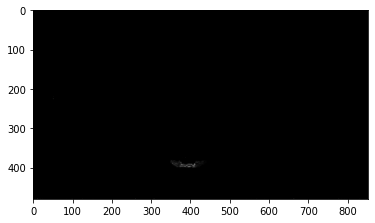

In [ ]:
plt.imshow(zResults[4], cmap = 'gray')

In [ ]:
arr = []
for k in range(5):
  arr.append()
print(arr)

In [ ]:
distFrames = []
distFrames.append(np.zeros(size))